In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, cohen_kappa_score, matthews_corrcoef

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 40
BATCH_SIZE = 16
LR = 1e-4   # 🔥 lowered for fine-tuning

TRAIN_PATH = r"F:\CV Project\LC25000\lung_colon_image_set\Train and Validation Set"
TEST_PATH  = r"F:\CV Project\LC25000\lung_colon_image_set\Test Set"

TARGET_CLASSES = ['colon_aca', 'colon_n']

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),  # 🔥 important
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [4]:
class FilteredImageFolder(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir)
        self.transform = transform
        
        self.classes = sorted(classes)
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = []

        for path, label in self.dataset.samples:
            class_name = self.dataset.classes[label]
            if class_name in self.classes:
                self.samples.append((path, self.class_to_idx[class_name]))

        print("Loaded:", len(self.samples), "samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        try:
            image = Image.open(path).convert("RGB")
        except:
            image = Image.new("RGB", (224, 224))

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
full_dataset = FilteredImageFolder(TRAIN_PATH, TARGET_CLASSES, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = FilteredImageFolder(TEST_PATH, TARGET_CLASSES, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Loaded: 9000 samples
Loaded: 1000 samples


In [6]:
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

# 🔥 Less freezing (important fix)
for param in model.features[:2].parameters():
    param.requires_grad = False

for param in model.features[2:].parameters():
    param.requires_grad = True

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

model = model.to(device)

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.3  # 🔥 use loss
)

In [8]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS):
    best_loss = float('inf')
    patience = 5
    counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)

        model.eval()
        val_loss, val_correct = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f}, Acc={val_acc:.4f}")

        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping")
            break

In [9]:
train_model(model, train_loader, val_loader)

Epoch 1: Train Loss=0.1688, Acc=0.9879 | Val Loss=0.1215, Acc=0.9994
Epoch 2: Train Loss=0.1265, Acc=0.9982 | Val Loss=0.1192, Acc=1.0000
Epoch 3: Train Loss=0.1223, Acc=0.9996 | Val Loss=0.1182, Acc=1.0000
Epoch 4: Train Loss=0.1202, Acc=0.9999 | Val Loss=0.1179, Acc=1.0000
Epoch 5: Train Loss=0.1200, Acc=0.9999 | Val Loss=0.1180, Acc=1.0000
Epoch 6: Train Loss=0.1192, Acc=1.0000 | Val Loss=0.1174, Acc=1.0000
Epoch 7: Train Loss=0.1188, Acc=1.0000 | Val Loss=0.1173, Acc=1.0000
Epoch 8: Train Loss=0.1188, Acc=1.0000 | Val Loss=0.1173, Acc=1.0000
Epoch 9: Train Loss=0.1187, Acc=1.0000 | Val Loss=0.1172, Acc=1.0000
Epoch 10: Train Loss=0.1188, Acc=1.0000 | Val Loss=0.1172, Acc=1.0000
Epoch 11: Train Loss=0.1192, Acc=0.9997 | Val Loss=0.1172, Acc=1.0000
Epoch 12: Train Loss=0.1188, Acc=1.0000 | Val Loss=0.1171, Acc=1.0000
Epoch 13: Train Loss=0.1186, Acc=1.0000 | Val Loss=0.1172, Acc=1.0000
Epoch 14: Train Loss=0.1186, Acc=1.0000 | Val Loss=0.1171, Acc=1.0000
Epoch 15: Train Loss=0.1204, 

In [10]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

C:\Users\Bramha\AppData\Local\Temp\ipykernel_3868\1841358865.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


In [11]:
class_names = ['Colon_Adenocarcinoma', 'Colon_Normal']

print(classification_report(y_true, y_pred, target_names=class_names))

print("\nAdvanced Metrics:")
print("ROC-AUC:", roc_auc_score(y_true, y_pred))
print("Kappa:", cohen_kappa_score(y_true, y_pred))
print("MCC:", matthews_corrcoef(y_true, y_pred))

                      precision    recall  f1-score   support

Colon_Adenocarcinoma       1.00      1.00      1.00       500
        Colon_Normal       1.00      1.00      1.00       500

            accuracy                           1.00      1000
           macro avg       1.00      1.00      1.00      1000
        weighted avg       1.00      1.00      1.00      1000


Advanced Metrics:
ROC-AUC: 1.0
Kappa: 1.0
MCC: 1.0


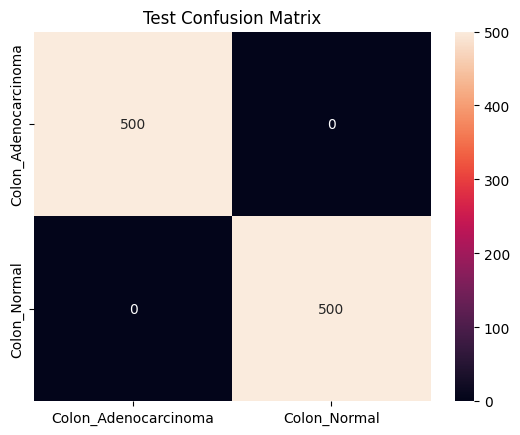

In [12]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Test Confusion Matrix")
plt.show()

In [13]:
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

print("Sample test paths:")
for i in range(5):
    print(test_dataset.samples[i][0])

Train samples: 7200
Test samples: 1000
Sample test paths:
F:\CV Project\LC25000\lung_colon_image_set\Test Set\colon_aca\colonca4273.jpeg
F:\CV Project\LC25000\lung_colon_image_set\Test Set\colon_aca\colonca4274.jpeg
F:\CV Project\LC25000\lung_colon_image_set\Test Set\colon_aca\colonca4275.jpeg
F:\CV Project\LC25000\lung_colon_image_set\Test Set\colon_aca\colonca4276.jpeg
F:\CV Project\LC25000\lung_colon_image_set\Test Set\colon_aca\colonca4277.jpeg


In [14]:
UNSEEN_PATH = r"F:\CV Project\LC25000\lung_colon_image_set\Test Set"

unseen_dataset = FilteredImageFolder(
    UNSEEN_PATH,
    TARGET_CLASSES,
    transform=val_transform
)

unseen_loader = DataLoader(unseen_dataset, batch_size=16, shuffle=False)

Loaded: 1000 samples


In [15]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in unseen_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

C:\Users\Bramha\AppData\Local\Temp\ipykernel_3868\3887754469.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


In [16]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [17]:
import random
y_pred_shuffled = y_pred.copy()
random.shuffle(y_pred_shuffled)

from sklearn.metrics import accuracy_score
print("Shuffled Accuracy:", accuracy_score(y_true, y_pred_shuffled))

Shuffled Accuracy: 0.47


In [18]:
for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        print("Found misclassification")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].


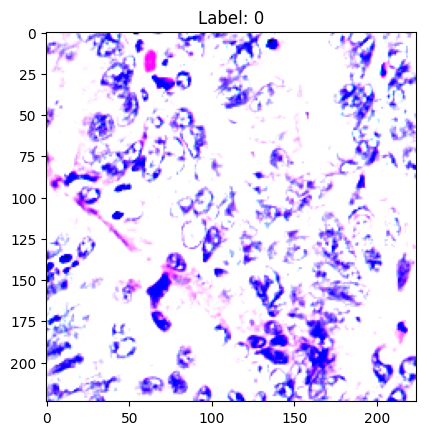

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.64].


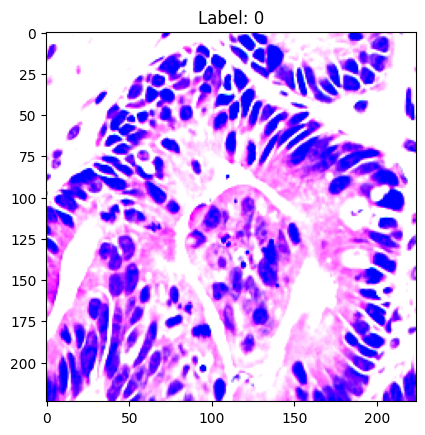

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.64].


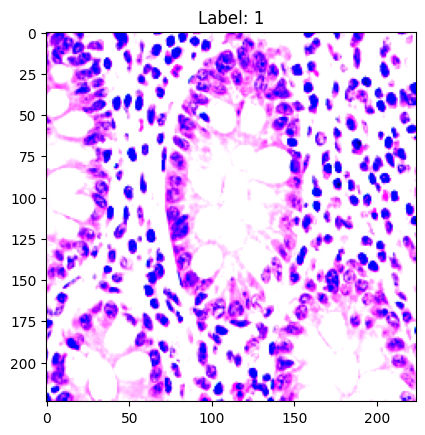

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0007002..2.64].


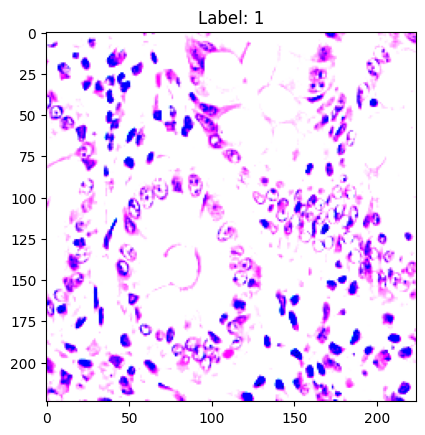

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].


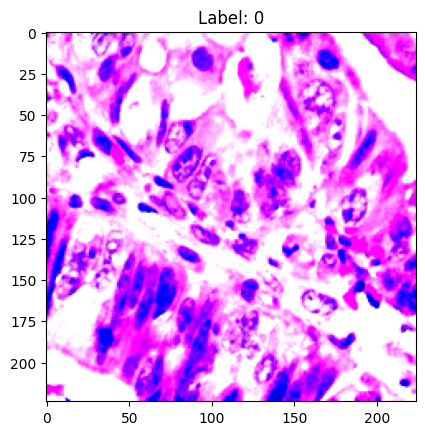

In [19]:
# check if images look visually similar
import matplotlib.pyplot as plt

for i in range(5):
    img, label = train_dataset[i]
    plt.imshow(img.permute(1,2,0))
    plt.title(f"Label: {label}")
    plt.show()